### Build Changepoint detection model on TAQ Trades with adaptive penalties 

In [1]:
import pandas as pd 
import numpy as np
from scipy.sparse import dia_matrix, csc_matrix
from scipy.sparse.linalg import inv
import matplotlib.pyplot as plt
from datetime import datetime
import sys
from scipy.interpolate import interp1d
from scipy.stats import iqr
import ruptures as rpt
from sklearn.model_selection import train_test_split
import time




path='/home/jbohn/jupyter/personal/'
sys.path.append(f'{path}TAQ-Query-Scripts/data')
sys.path.append(f'{path}Changepoint_LOB/Lasso/CPD')
from adaptive_tf_ir import l1tf_adaptive_ir, Dmat

### TAQ Data AAPL

Snippet of AAPL trades on NYSE for 1 hour

In [2]:
trades=pd.read_csv(f'{path}TAQ-Query-Scripts/data/cleaned_trades.csv',index_col=0)


trades=trades[trades.index < "2020-01-15 15:59:30"]
trades=trades[trades.index> "2020-01-15 15:55:00"]

trades['Trade_Price']=np.log(trades['Trade_Price'])
trades

,SIP_Timestamp,Exchange,Symbol,Trade_Volume,Trade_Price,Sale_Condition,Source_of_Trade,Trade_Correction_Indicator,Sequence_Number,Trade_Id,Trade_Reporting_Facility,Trade_Through_Exempt_Indicator,date
2020-01-15 15:55:00.167778,2020-01-15 15:55:00.168158,N,AAPL,200,5.739214,@F,N,0,2817965,5545,,1,2020-01-15
2020-01-15 15:55:00.527569,2020-01-15 15:55:00.527951,N,AAPL,100,5.739310,@F,N,0,2818349,5546,,1,2020-01-15
2020-01-15 15:55:02.214288,2020-01-15 15:55:02.214671,N,AAPL,66,5.739085,@ I,N,0,2819211,5547,,0,2020-01-15
2020-01-15 15:55:02.214497,2020-01-15 15:55:02.214876,N,AAPL,134,5.739085,@F,N,0,2819222,5548,,1,2020-01-15
2020-01-15 15:55:02.218917,2020-01-15 15:55:02.219296,N,AAPL,105,5.739182,@F,N,0,2819357,5549,,1,2020-01-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-15 15:59:25.573634,2020-01-15 15:59:25.574009,N,AAPL,46,5.740404,@ I,N,0,2937032,5653,,0,2020-01-15
2020-01-15 15:59:26.015345,2020-01-15 15:59:26.015721,N,AAPL,40,5.740436,@ I,N,0,2937404,5654,,0,2020-01-15
2020-01-15 15:59:29.176621,2020-01-15 15:59:29.177000,N,AAPL,97,5.740500,@ I,N,0,2939443,5655,,0,2020-01-15
2020-01-15 15:59:29.920769,2020-01-15 15:59:29.921147,N,AAPL,100,5.740661,@,N,0,2940442,5656,,0,2020-01-15


Text(0.5, 1.0, 'APPL Trade Price 01/15/2020')

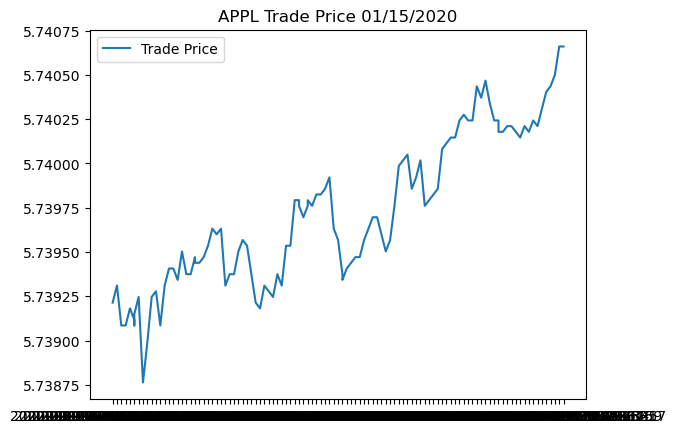

In [3]:
fig,ax=plt.subplots()
ax.plot(trades['Trade_Price'],label='Trade Price')
ax.legend()
ax.set_title("APPL Trade Price 01/15/2020")

In [4]:
vol=trades['Trade_Volume']

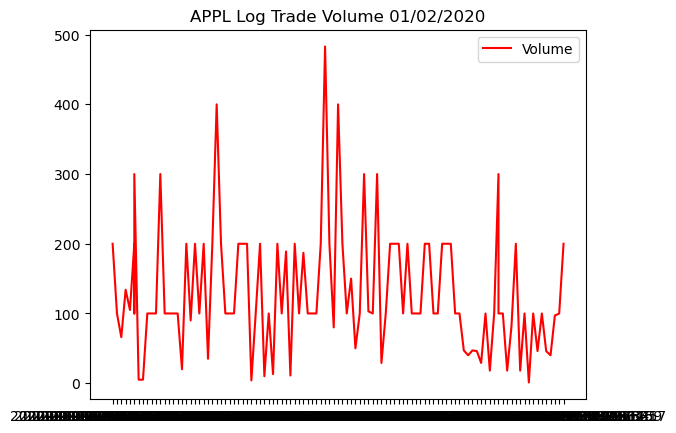

In [5]:
fig,ax=plt.subplots()
ax.set_title("APPL Log Trade Volume 01/02/2020")
ax.plot(vol,color='red',label='Volume')
ax.legend()

### Extension for irregularly spaced time and Adaptive Penalty

### Unit Test 1

For both unit tests we pass in an array of differences in time 

For each trend filtering problem, the filtered signal is returned with the normalized D_DT Inverse



In [21]:
t=np.arange(0,len(trades.index))
t1=np.cumsum(np.pad(np.diff(t),(1,0),'constant',constant_values=t[1]))

In [22]:

y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt1,status,eq_D=l1tf_adaptive_ir(y,t=t1,lambda_p=0.0010)

pobj1: [[0.22200181]], pobj2: [[1.38611019e-05]], dobj: [[0.]], gap: [[1.38611019e-05]]
pobj1: [[3081.94110942]], pobj2: [[1.37976487e-05]], dobj: [[1.64703514e-09]], gap: [[1.37960017e-05]]
pobj1: [[12.89888829]], pobj2: [[1.05744391e-05]], dobj: [[8.30875664e-08]], gap: [[1.04913515e-05]]
pobj1: [[0.3087647]], pobj2: [[3.61389184e-06]], dobj: [[3.0416289e-07]], gap: [[3.30972895e-06]]
pobj1: [[0.03653138]], pobj2: [[1.80689354e-06]], dobj: [[4.89313769e-07]], gap: [[1.31757977e-06]]
pobj1: [[0.01144604]], pobj2: [[1.31150035e-06]], dobj: [[6.19955371e-07]], gap: [[6.91544974e-07]]
pobj1: [[0.02715224]], pobj2: [[1.25019086e-06]], dobj: [[6.8212641e-07]], gap: [[5.68064446e-07]]
pobj1: [[0.05024784]], pobj2: [[1.20672215e-06]], dobj: [[7.32950391e-07]], gap: [[4.73771755e-07]]
pobj1: [[0.00839055]], pobj2: [[1.15606704e-06]], dobj: [[7.76393179e-07]], gap: [[3.79673861e-07]]
pobj1: [[0.00278206]], pobj2: [[1.10149679e-06]], dobj: [[8.23201172e-07]], gap: [[2.78295615e-07]]
pobj1: [[0.

In [23]:
print(np.linalg.cond(eq_D))
print(np.round(eq_D,4))
print(np.linalg.cond(eq_D))

2282.3609440751566
[[ 1. -2.  1. ...  0.  0.  0.]
 [ 0.  1. -2. ...  0.  0.  0.]
 [ 0.  0.  1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  1.  0.  0.]
 [ 0.  0.  0. ... -2.  1.  0.]
 [ 0.  0.  0. ...  1. -2.  1.]]
2282.3609440751566


Note the equivalence in difference matrix

Text(0.5, 1.0, 'Adaptive Trend Filtering APPL Trade Price 01/06/2020')

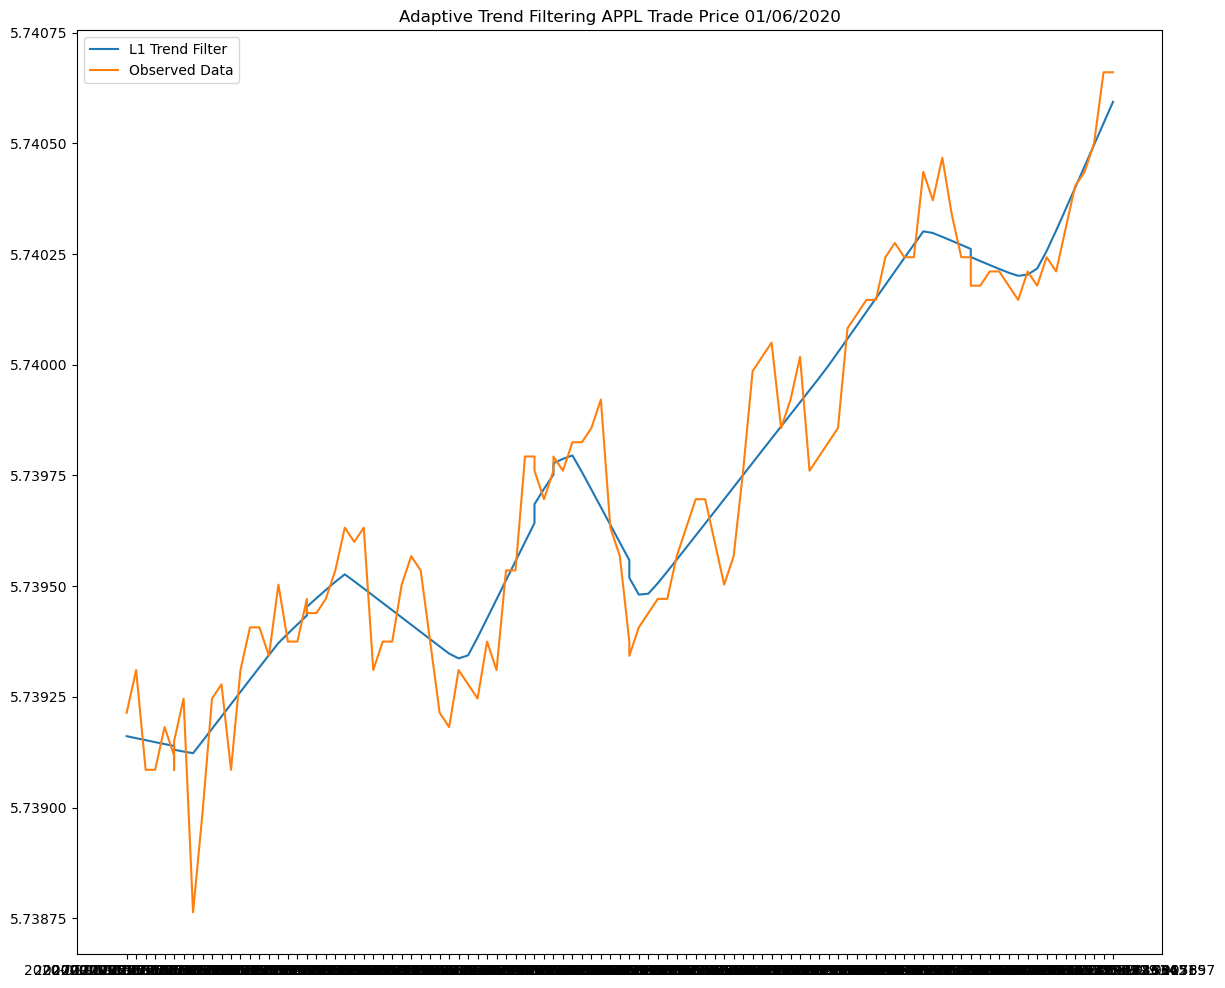

In [24]:
fig,ax=plt.subplots(figsize=(14,12))
ax.plot(trades.index,x_adapt1,label= 'L1 Trend Filter')
ax.plot(trades.index,y, label='Observed Data')


ax.legend()
ax.set_title("Adaptive Trend Filtering APPL Trade Price 01/06/2020")

### Unit Test 2

Uniformly sampled data within the range (0.999999,1.000001)

Leads me to believe the optimization is ill=conditioned 

In [55]:
a=0.9999
b=1.0001

t2=t1[-21]+np.cumsum(np.random.rand(20)*(b-a)+a)

t2=np.concatenate([t1[:-20],t2])
t2

array([  1.        ,   2.        ,   3.        ,   4.        ,
         5.        ,   6.        ,   7.        ,   8.        ,
         9.        ,  10.        ,  11.        ,  12.        ,
        13.        ,  14.        ,  15.        ,  16.        ,
        17.        ,  18.        ,  19.        ,  20.        ,
        21.        ,  22.        ,  23.        ,  24.        ,
        25.        ,  26.        ,  27.        ,  28.        ,
        29.        ,  30.        ,  31.        ,  32.        ,
        33.        ,  34.        ,  35.        ,  36.        ,
        37.        ,  38.        ,  39.        ,  40.        ,
        41.        ,  42.        ,  43.        ,  44.        ,
        45.        ,  46.        ,  47.        ,  48.        ,
        49.        ,  50.        ,  51.        ,  52.        ,
        53.        ,  54.        ,  55.        ,  56.        ,
        57.        ,  58.        ,  59.        ,  60.        ,
        61.        ,  62.        ,  63.        ,  64.  

In [56]:

y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt2,status,D_2=l1tf_adaptive_ir(y,t=t2,lambda_p=0.001)

pobj1: [[0.23402869]], pobj2: [[2.4396576e-05]], dobj: [[0.]], gap: [[2.4396576e-05]]
pobj1: [[3290.21738426]], pobj2: [[2.43310398e-05]], dobj: [[6.6217448e-09]], gap: [[2.43244181e-05]]
pobj1: [[65.4392899]], pobj2: [[2.11595098e-05]], dobj: [[4.22658064e-07]], gap: [[2.07368517e-05]]
pobj1: [[60.35291614]], pobj2: [[1.76676386e-05]], dobj: [[3.37354481e-06]], gap: [[1.42940938e-05]]
pobj1: [[138.20919356]], pobj2: [[1.67086553e-05]], dobj: [[5.62056275e-06]], gap: [[1.10880925e-05]]
pobj1: [[469.64449634]], pobj2: [[1.64629791e-05]], dobj: [[5.99798744e-06]], gap: [[1.04649916e-05]]
pobj1: [[1248.37221936]], pobj2: [[1.61208356e-05]], dobj: [[6.53785687e-06]], gap: [[9.58297871e-06]]
pobj1: [[1755.6211397]], pobj2: [[1.54119536e-05]], dobj: [[6.958874e-06]], gap: [[8.45307963e-06]]
pobj1: [[161.74923956]], pobj2: [[1.46567049e-05]], dobj: [[7.4904857e-06]], gap: [[7.16621919e-06]]
pobj1: [[207.71443813]], pobj2: [[1.38498116e-05]], dobj: [[7.68316687e-06]], gap: [[6.16664472e-06]]
p

In [57]:
print(np.round(D_2,4))

print(np.linalg.matrix_rank(D_2),D_2.shape)
print(np.linalg.cond(D_2))

[[ 1.     -2.      1.     ...  0.      0.      0.    ]
 [ 0.      1.     -2.     ...  0.      0.      0.    ]
 [ 0.      0.      1.     ...  0.      0.      0.    ]
 ...
 [ 0.      0.      0.     ...  1.      0.      0.    ]
 [ 0.      0.      0.     ... -2.      1.      0.    ]
 [ 0.      0.      0.     ...  1.     -1.9999  1.    ]]
111 (111, 113)
2284.835722491683


### Unit Test 3

In [58]:
a=0.99
b=1.01

t3=t1[-21]+np.cumsum(np.random.rand(20)*(b-a)+a)

t3=np.concatenate([t1[:-20],t3])
t3

array([  1.        ,   2.        ,   3.        ,   4.        ,
         5.        ,   6.        ,   7.        ,   8.        ,
         9.        ,  10.        ,  11.        ,  12.        ,
        13.        ,  14.        ,  15.        ,  16.        ,
        17.        ,  18.        ,  19.        ,  20.        ,
        21.        ,  22.        ,  23.        ,  24.        ,
        25.        ,  26.        ,  27.        ,  28.        ,
        29.        ,  30.        ,  31.        ,  32.        ,
        33.        ,  34.        ,  35.        ,  36.        ,
        37.        ,  38.        ,  39.        ,  40.        ,
        41.        ,  42.        ,  43.        ,  44.        ,
        45.        ,  46.        ,  47.        ,  48.        ,
        49.        ,  50.        ,  51.        ,  52.        ,
        53.        ,  54.        ,  55.        ,  56.        ,
        57.        ,  58.        ,  59.        ,  60.        ,
        61.        ,  62.        ,  63.        ,  64.  

In [59]:


y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt3,status,D_3=l1tf_adaptive_ir(y,t=t3,lambda_p=0.0010)

pobj1: [[49.29743686]], pobj2: [[0.00132697]], dobj: [[0.]], gap: [[0.00132697]]
pobj1: [[171943.1996226]], pobj2: [[0.00132609]], dobj: [[5.52101459e-05]], gap: [[0.00127088]]
pobj1: [[141001.86969925]], pobj2: [[0.00132136]], dobj: [[0.00033648]], gap: [[0.00098488]]
pobj1: [[351338.48083266]], pobj2: [[0.00131816]], dobj: [[0.0004731]], gap: [[0.00084506]]
pobj1: [[1064430.77946284]], pobj2: [[0.00131694]], dobj: [[0.00051661]], gap: [[0.00080034]]
pobj1: [[3007802.01587815]], pobj2: [[0.00131606]], dobj: [[0.00054813]], gap: [[0.00076793]]
pobj1: [[7939715.87407204]], pobj2: [[0.00131555]], dobj: [[0.000568]], gap: [[0.00074755]]
pobj1: [[10989025.01735601]], pobj2: [[0.00131518]], dobj: [[0.00058639]], gap: [[0.00072878]]
pobj1: [[26879143.46418065]], pobj2: [[0.001315]], dobj: [[0.0005964]], gap: [[0.0007186]]
pobj1: [[30805612.59103515]], pobj2: [[0.00131485]], dobj: [[0.00060807]], gap: [[0.00070678]]
pobj1: [[578842.98177264]], pobj2: [[0.00131502]], dobj: [[0.00061832]], gap:

In [60]:
print(np.round(D_3,4))

print(np.linalg.matrix_rank(D_3),D_3.shape)
print(np.linalg.cond(D_3))

[[ 1.     -2.      1.     ...  0.      0.      0.    ]
 [ 0.      1.     -2.     ...  0.      0.      0.    ]
 [ 0.      0.      1.     ...  0.      0.      0.    ]
 ...
 [ 0.      0.      0.     ...  0.9995  0.      0.    ]
 [ 0.      0.      0.     ... -2.0011  1.0096  0.    ]
 [ 0.      0.      0.     ...  1.     -1.9809  1.0096]]
111 (111, 113)
2078.954022258784


In [61]:
a=0
b=2

t4=t1[-21]+np.cumsum(np.random.rand(20)*(b-a)+a)

t4=np.concatenate([t1[:-20],t4])
t4

array([  1.        ,   2.        ,   3.        ,   4.        ,
         5.        ,   6.        ,   7.        ,   8.        ,
         9.        ,  10.        ,  11.        ,  12.        ,
        13.        ,  14.        ,  15.        ,  16.        ,
        17.        ,  18.        ,  19.        ,  20.        ,
        21.        ,  22.        ,  23.        ,  24.        ,
        25.        ,  26.        ,  27.        ,  28.        ,
        29.        ,  30.        ,  31.        ,  32.        ,
        33.        ,  34.        ,  35.        ,  36.        ,
        37.        ,  38.        ,  39.        ,  40.        ,
        41.        ,  42.        ,  43.        ,  44.        ,
        45.        ,  46.        ,  47.        ,  48.        ,
        49.        ,  50.        ,  51.        ,  52.        ,
        53.        ,  54.        ,  55.        ,  56.        ,
        57.        ,  58.        ,  59.        ,  60.        ,
        61.        ,  62.        ,  63.        ,  64.  

In [62]:

y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt4,status,D_4=l1tf_adaptive_ir(y,t=t4,lambda_p=0.001)

pobj1: [[673.07738504]], pobj2: [[1.08186586]], dobj: [[0.]], gap: [[1.08186586]]
pobj1: [[24729922.92134565]], pobj2: [[1.07584499]], dobj: [[0.39026657]], gap: [[0.68557842]]
pobj1: [[1.53910675e+08]], pobj2: [[1.07317354]], dobj: [[0.70404675]], gap: [[0.36912679]]
pobj1: [[6.75633416e+08]], pobj2: [[1.07254146]], dobj: [[0.88169016]], gap: [[0.1908513]]
pobj1: [[2.76162752e+09]], pobj2: [[1.07251169]], dobj: [[0.92726581]], gap: [[0.14524588]]
pobj1: [[1.10871863e+10]], pobj2: [[1.07251132]], dobj: [[0.93017171]], gap: [[0.14233961]]
pobj1: [[4.2793752e+10]], pobj2: [[1.07251015]], dobj: [[0.92382026]], gap: [[0.14868989]]
pobj1: [[1.68923465e+11]], pobj2: [[1.07250753]], dobj: [[0.93185234]], gap: [[0.1406552]]
pobj1: [[6.62887064e+11]], pobj2: [[1.07250707]], dobj: [[0.93714028]], gap: [[0.13536679]]
pobj1: [[1.01793404e+12]], pobj2: [[1.07250286]], dobj: [[0.93590512]], gap: [[0.13659774]]
pobj1: [[2.66516649e+12]], pobj2: [[1.07250091]], dobj: [[0.96139233]], gap: [[0.11110859]

In [63]:
print(np.round(D_4,4))

print(np.linalg.matrix_rank(D_4),D_4.shape)
print(np.linalg.cond(D_4))

[[ 1.     -2.      1.     ...  0.      0.      0.    ]
 [ 0.      1.     -2.     ...  0.      0.      0.    ]
 [ 0.      0.      1.     ...  0.      0.      0.    ]
 ...
 [ 0.      0.      0.     ...  0.6441  0.      0.    ]
 [ 0.      0.      0.     ... -3.1051  1.5905  0.    ]
 [ 0.      0.      0.     ...  1.     -1.2574  1.5905]]
111 (111, 113)
75329.54699870321


### Partially irregular time to display the instability 

Text(0.5, 0.98, 'Adaptive Trend Filtering APPL Trade Price 01/06/2020')

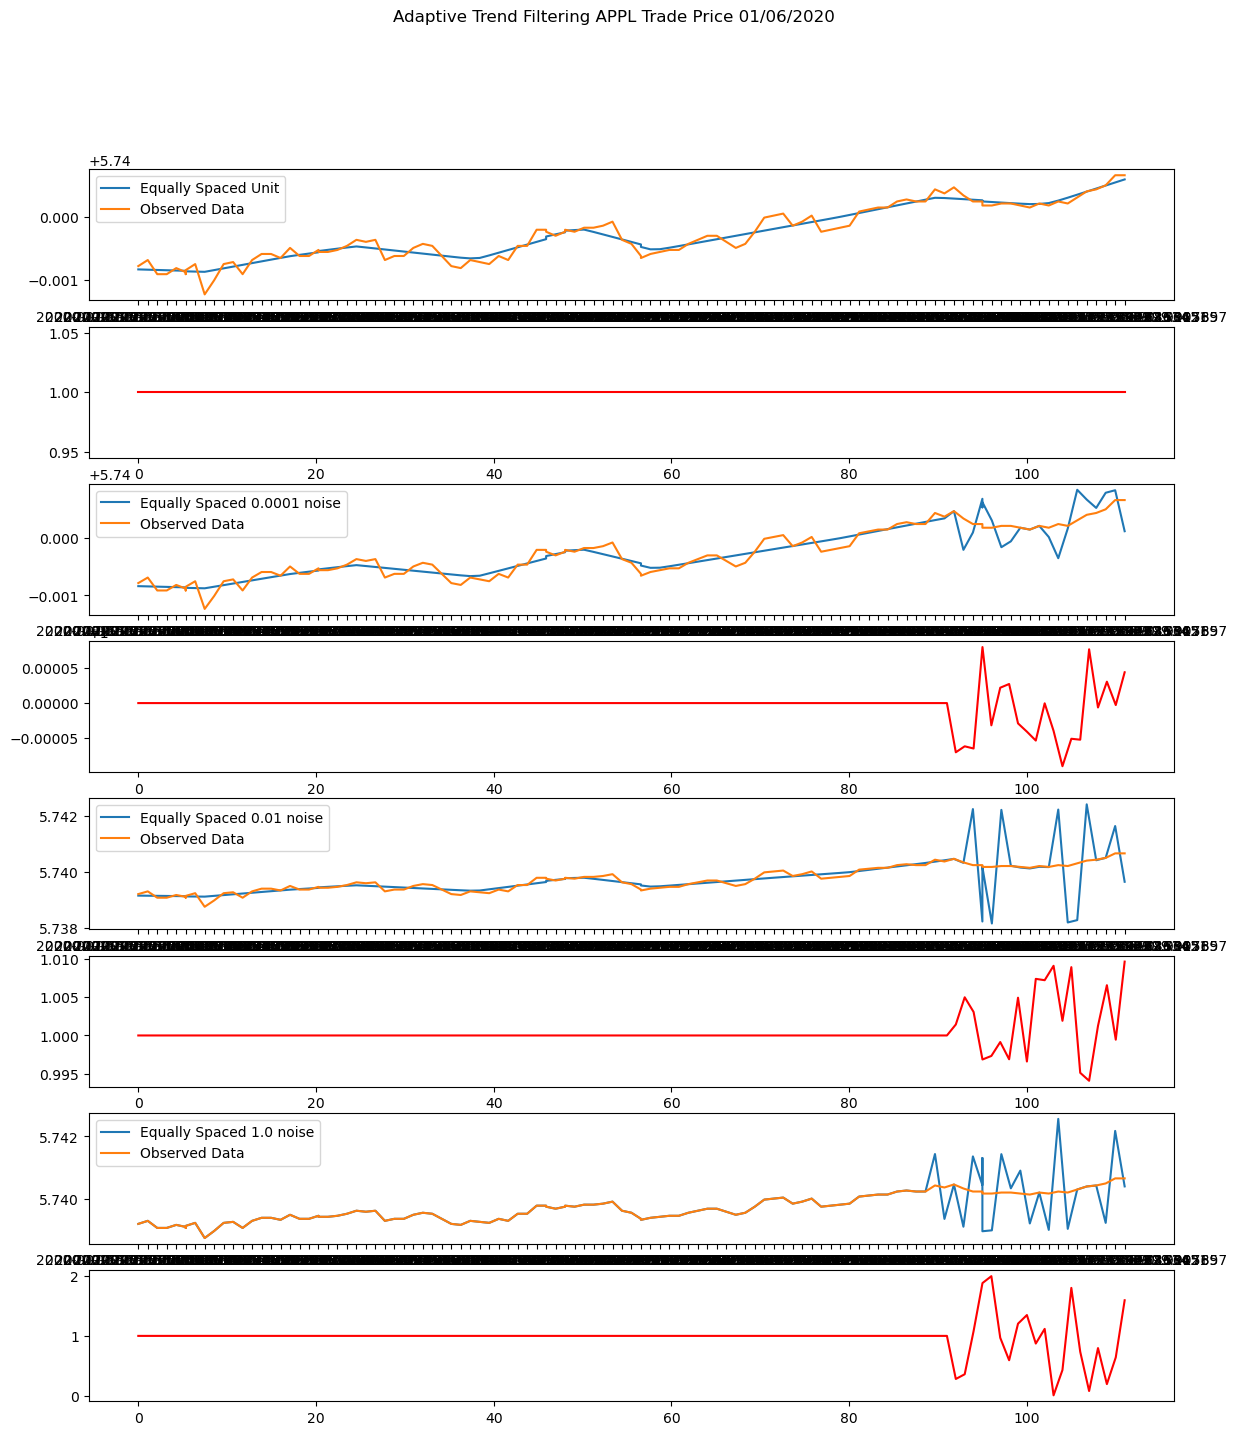

In [64]:
fig,ax=plt.subplots(8,1,figsize=(14,16))
ax[0].plot(trades.index,x_adapt1,label= 'Equally Spaced Unit')
ax[0].plot(trades.index,y, label='Observed Data')

ax[1].plot(np.diff(t1),color='red')

ax[2].plot(trades.index,x_adapt2,label= 'Equally Spaced 0.0001 noise')
ax[2].plot(trades.index,y, label='Observed Data')

ax[3].plot(np.diff(t2),color='red')

ax[4].plot(trades.index,x_adapt3,label= 'Equally Spaced 0.01 noise')
ax[4].plot(trades.index,y, label='Observed Data')

ax[5].plot(np.diff(t3),color='red')

ax[6].plot(trades.index,x_adapt4,label= 'Equally Spaced 1.0 noise')
ax[6].plot(trades.index,y, label='Observed Data')

ax[7].plot(np.diff(t4),color='red')

ax[0].legend()
ax[2].legend()
ax[4].legend()
ax[6].legend()

fig.suptitle("Adaptive Trend Filtering APPL Trade Price 01/06/2020")